# Ensemble

In this notebook the whole Ensemble will be created, first all the components (detector, classifier and VIT-model) will ve loaded and used in eval mode, so that their weights are freezed. Then an Additional Feed forward NN is created and trained tor predict the countrylabel from the concatenated outputs of the submodels.

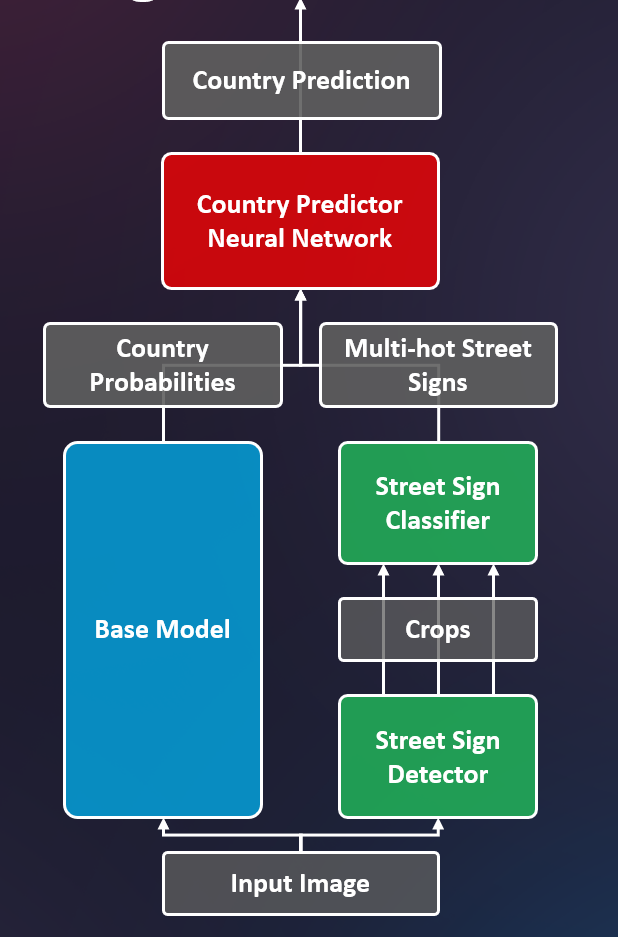

## Imports

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np
from ultralytics import YOLO
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision import transforms
import os
import timm

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

E:\DataMiningProj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Helper methods
Method to derive the multi hot encoding, that is fed into the top level feed forward NN, from street sign (+ region code) predictions

In [10]:
# Not needed in final state
def street_signs_to_multihot(detections, sign_classes):
    """
    detections: output of detect_and_classify
    sign_classes: list of all possible street-sign labels
    returns: multi-hot vector [num_signs]
    """
    multihot = torch.zeros(len(sign_classes), dtype=torch.float32)
    for det in detections:
        if det["label"] in sign_classes:
            idx = sign_classes.index(det["label"])
            multihot[idx] = 1.0
    return multihot

## Load sub-models

#### VIT-model

In [43]:
class ViTModel(nn.Module):
    def __init__(self, num_classes, pretrained=True):
        super(ViTModel, self).__init__()

        # Create ViT base model
        self.vit = timm.create_model("vit_base_patch16_224", pretrained=pretrained)

        # Replace classification head
        self.vit.head = nn.Linear(self.vit.head.in_features, num_classes)

    def forward(self, x):
        return self.vit(x)

checkpoint = torch.load('ViTModel/best.pth', map_location=torch.device('cpu'))
model = ViTModel(num_classes=len(checkpoint["label_map"]), pretrained=False)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

ViTModel(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): G

In [12]:
# -------------------------------
# 2. Wrappers for pretrained models
# -------------------------------

class ViTWrapper(nn.Module):
    """Wrapper for the ViT model producing country logits"""
    def __init__(self, vit_model):
        super().__init__()
        self.vit = vit_model
        self.vit.eval()  # freeze weights

    def forward(self, x):
        with torch.no_grad():
            logits = self.vit(x)  # [B, num_countries]
            probs = torch.softmax(logits, dim=1)
        return probs  # [B, num_countries]

#### YOLO model (Street-Sign Detector)

In [13]:
yolo_model = YOLO("runs/detect/yolov8s_mapillary_subset_cpu10/weights/best.pt")

#### Street-Sign Classifier

In [14]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.datasets import ImageFolder

train_dir = "crops_per_label"

dataset = ImageFolder(train_dir)
class_names = dataset.classes   # SORTED and consistent
num_classes = len(class_names)

weights = EfficientNet_B0_Weights.DEFAULT
classifier = efficientnet_b0(weights=weights)
classifier.classifier[1] = torch.nn.Linear(
    classifier.classifier[1].in_features,
    num_classes
)

classifier.load_state_dict(
    torch.load("street_sign_classifier_weights.pth", map_location="cpu")
)
classifier.eval()

classifier_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#### Method that runs whole Street-Sign pipeline

In [15]:
def detect_and_classify(image_path, conf_threshold=0.3):
    """
    Input: full image path
    Output: list of dicts with detected labels and confidences
    """
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    # YOLO detection
    results = yolo_model(image_np, conf=conf_threshold, verbose=False)[0]

    outputs = []

    if results.boxes is None:
        return outputs

    for box in results.boxes:
        # Bounding box
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        det_conf = float(box.conf[0])

        # Crop detected region
        crop = image.crop((x1, y1, x2, y2))

        # Classifier inference
        input_tensor = classifier_transform(crop).unsqueeze(0)

        with torch.no_grad():
            logits = classifier(input_tensor)
            probs = torch.softmax(logits, dim=1)
            cls_idx = probs.argmax(dim=1).item()
            cls_conf = probs[0, cls_idx].item()

        outputs.append({
            "label": class_names[cls_idx],
            "cls_conf": cls_conf,
            "det_conf": det_conf
        })

    return outputs


In [16]:
class StreetSignWrapper(nn.Module):
    """Wrapper for the street sign model producing multi-hot vector"""
    def __init__(self, detect_fn, class_names):
        """
        detect_fn: function that takes image path and returns list of dicts with 'label'
        class_names: list of all possible street sign labels
        """
        super().__init__()
        self.detect_fn = detect_fn
        self.class_names = class_names
        self.num_sign_classes = len(class_names)
        self.label_to_idx = {label: idx for idx, label in enumerate(class_names)}

    def forward(self, image_paths):
        """
        image_paths: list of file paths for a batch
        returns: tensor [B, num_sign_classes] multi-hot
        """
        batch_vectors = []

        for path in image_paths:
            outputs = self.detect_fn(path)  # list of dicts with 'label'
            vec = torch.zeros(self.num_sign_classes)  # initialize multi-hot vector

            for out in outputs:
                label = out["label"]
                if label in self.label_to_idx:
                    vec[self.label_to_idx[label]] = 1.0  # set 1 if detected

            batch_vectors.append(vec)

        return torch.stack(batch_vectors, dim=0)  # [B, num_sign_classes]

## Top Level feed forward NN

In [17]:
class EnsembleModel(nn.Module):
    def __init__(self, vit_feat_dim, num_sign_classes, num_countries, hidden_dim=256):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(vit_feat_dim + num_sign_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_countries)
        )

    def forward(self, vit_features, sign_vec):
        x = torch.cat([vit_features, sign_vec], dim=1)
        return self.fc(x)


## Prepare dataset
For training parts of the sylvia shaw dataset is used

In [18]:
import os

data_dir = "E:/DataMiningProj/data/datasets/sylshaw/streetview-by-country/versions/2/streetview_images"
image_root = data_dir
image_paths_list = []
labels_list = []

max_images_per_country = 30

# Walk through folders
for country_code in os.listdir(data_dir):
    country_folder = os.path.join(data_dir, country_code)
    if os.path.isdir(country_folder):
        # Get all image files in the folder
        all_images = [f for f in os.listdir(country_folder)
                      if f.lower().endswith((".jpg", ".jpeg", ".png"))]
        # Sort for consistency and take only the first `max_images_per_country`
        all_images = sorted(all_images)[:max_images_per_country]

        for fname in all_images:
            image_paths_list.append(os.path.join(country_folder, fname))
            labels_list.append(country_code)

# Create mapping country code -> index
country_codes = sorted(list(set(labels_list)))
country_to_idx = {code: idx for idx, code in enumerate(country_codes)}

# Convert labels to integers for PyTorch
labels_int = [country_to_idx[label] for label in labels_list]

print(f"Total images loaded: {len(image_paths_list)}")


class CountryEnsembleDataset(Dataset):
    """Dataset that returns images for ViT and paths for street sign model"""
    def __init__(self, image_paths, labels, vit_transform):
        """
        image_paths: list of file paths
        labels: list of integer country indices
        vit_transform: transforms for ViT input
        """
        self.image_paths = image_paths
        self.labels = labels
        self.vit_transform = vit_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        vit_tensor = self.vit_transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)  # now safe
        return vit_tensor, img_path, label


Total images loaded: 3330


## Training

In [20]:
def train_ensemble(vit_wrapper, sign_wrapper, ensemble_model,
                   dataloader, device, epochs=10, lr=1e-3, save_path="ensemble.pth"):

    vit_wrapper.eval()  # frozen
    sign_wrapper.eval()  # frozen

    ensemble_model = ensemble_model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(ensemble_model.parameters(), lr=lr)

    for epoch in range(epochs):
        ensemble_model.train()
        total_loss = 0
        for vit_tensor, img_paths, labels in dataloader:
            vit_tensor = vit_tensor.to(device)
            labels = labels.to(device)

            # ----------------------
            # Forward pass
            # ----------------------
            with torch.no_grad():
                vit_probs = vit_wrapper(vit_tensor)  # [B, num_countries]

            sign_vec = sign_wrapper(img_paths).to(device)  # [B, num_sign_classes]

            logits = ensemble_model(vit_probs, sign_vec)
            loss = criterion(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * vit_tensor.size(0)

        avg_loss = total_loss / len(dataloader.dataset)
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}")

        # Save checkpoint
        torch.save({
            "epoch": epoch+1,
            "ensemble_state_dict": ensemble_model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict()
        }, save_path)

    print("Training complete. Ensemble model saved to:", save_path)

In [21]:
#set up
import torchvision.transforms as transforms

# Example: load your ViT model
vit_num_classes = len(checkpoint["label_map"])
vit_model = ViTModel(num_classes=vit_num_classes, pretrained=False)
vit_model.load_state_dict(checkpoint["model_state_dict"])
vit_wrapper = ViTWrapper(vit_model)

# Example: load street sign model wrapper
sign_wrapper = StreetSignWrapper(detect_fn=detect_and_classify,
                                 class_names=class_names)

# Ensemble model
num_countries_new = len(country_codes)   # new dataset
num_sign_classes = len(class_names)      # street sign classes
vit_feat_dim = vit_num_classes   # original ViT output size (fixed, frozen)

ensemble_model = EnsembleModel(
    vit_feat_dim=vit_feat_dim,
    num_sign_classes=num_sign_classes,
    num_countries=num_countries_new,
    hidden_dim=256
)

# Dataset + dataloader
vit_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5))
])

# Freeze ViT
for param in vit_wrapper.parameters():
    param.requires_grad = False

# Freeze street sign model
for param in sign_wrapper.parameters():
    param.requires_grad = False

dataset = CountryEnsembleDataset(image_paths=image_paths_list,
                                 labels=labels_int,
                                 vit_transform=vit_transform)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

In [ ]:
# Train ensemble
train_ensemble(vit_wrapper, sign_wrapper, ensemble_model,
               dataloader, device=DEVICE, epochs=6, lr=1e-3,
               save_path="ensemble_checkpoint.pth")

## inference on one image

In [22]:
import torch.nn.functional as F

def predict_country(image_path, top_k=5):
    """
    Runs ensemble inference on a single image
    Returns top-k predicted countries
    """

    # ---- ViT input ----
    image = Image.open(image_path).convert("RGB")
    vit_tensor = vit_transform(image).unsqueeze(0).to(DEVICE)

    # ---- Forward pass ----
    with torch.no_grad():
        # ViT probabilities (frozen)
        vit_probs = vit_wrapper(vit_tensor)  # [1, vit_feat_dim]

        # Street sign multi-hot vector
        sign_vec = sign_wrapper([image_path]).to(DEVICE)  # [1, num_sign_classes]

        # Ensemble logits
        logits = ensemble_model(vit_probs, sign_vec)

        probs = F.softmax(logits, dim=1)[0]

    # ---- Top-k results ----
    top_probs, top_idxs = torch.topk(probs, top_k)

    predictions = []
    for p, idx in zip(top_probs, top_idxs):
        country = country_codes[idx.item()]
        predictions.append((country, float(p)))

    return predictions

In [51]:
image_path = "E:/DataMiningProj/data/datasets/sylshaw/streetview-by-country/versions/2/streetview_images/DK/54d603920_11d950004_h63.jpg"

predictions = predict_country(image_path, top_k=5)

print("Top predictions:")
for country, prob in predictions:
    print(f"{country}: {prob:.3f}")

Top predictions:
DK: 0.509
PL: 0.086
SE: 0.055
CZ: 0.027
HU: 0.026


## evaluate ensemble

In [24]:
import os
import random

data_dir = "E:/DataMiningProj/data/datasets/sylshaw/streetview-by-country/versions/2/streetview_images"

num_train = 30
num_test = 30

random.seed(42)  # reproducibility

train_image_paths = []
train_labels = []

test_image_paths = []
test_labels = []

for country_code in os.listdir(data_dir):
    country_folder = os.path.join(data_dir, country_code)
    if not os.path.isdir(country_folder):
        continue

    images = sorted([
        f for f in os.listdir(country_folder)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    if len(images) <= num_train:
        continue

    train_imgs = images[:num_train]
    remaining_imgs = images[num_train:]

    if len(remaining_imgs) < num_test:
        continue

    test_imgs = random.sample(remaining_imgs, num_test)

    for f in train_imgs:
        train_image_paths.append(os.path.join(country_folder, f))
        train_labels.append(country_code)

    for f in test_imgs:
        test_image_paths.append(os.path.join(country_folder, f))
        test_labels.append(country_code)


In [5]:
country_codes = sorted(set(train_labels))
country_to_idx = {c: i for i, c in enumerate(country_codes)}
idx_to_country = {i: c for c, i in country_to_idx.items()}

train_labels_int = [country_to_idx[c] for c in train_labels]
test_labels_int  = [country_to_idx[c] for c in test_labels]


In [6]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

class CountryEnsembleDataset(Dataset):
    def __init__(self, image_paths, labels, vit_transform):
        self.image_paths = image_paths
        self.labels = labels
        self.vit_transform = vit_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        vit_tensor = self.vit_transform(image)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return vit_tensor, img_path, label


In [26]:
test_dataset = CountryEnsembleDataset(
    image_paths=test_image_paths,
    labels=test_labels_int,
    vit_transform=vit_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)


In [33]:
import torch

# Initialize your ensemble model (must match the architecture used in training)
#ensemble_model = EnsembleModel(...)  # replace with your actual class and args

# Load checkpoint
checkpoint = torch.load("ensemble_checkpoint.pth", map_location=DEVICE)

# Restore model weights
ensemble_model.load_state_dict(checkpoint["ensemble_state_dict"])
ensemble_model.to(DEVICE)
ensemble_model.eval()  # important for evaluation!

# Optional: restore optimizer if you want to continue training
# optimizer = torch.optim.Adam(ensemble_model.parameters(), lr=1e-3)
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print(f"Ensemble model loaded from epoch {checkpoint['epoch']}")


Ensemble model loaded from epoch 6


In [34]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_ensemble(vit_wrapper, sign_wrapper, ensemble_model,
                      dataloader, device, top_k=5):

    vit_wrapper.eval()
    sign_wrapper.eval()
    ensemble_model.eval()

    correct = 0
    correct_topk = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for vit_tensor, img_paths, labels in tqdm(dataloader):
            vit_tensor = vit_tensor.to(device)
            labels = labels.to(device)

            vit_probs = vit_wrapper(vit_tensor)
            sign_vec = sign_wrapper(img_paths).to(device)

            logits = ensemble_model(vit_probs, sign_vec)
            probs = F.softmax(logits, dim=1)

            preds = probs.argmax(dim=1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            # Top-k accuracy
            topk_preds = torch.topk(probs, top_k, dim=1).indices
            correct_topk += sum(
                labels[i] in topk_preds[i] for i in range(labels.size(0))
            )

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    acc = correct / total
    topk_acc = correct_topk / total

    # Calculate precision, recall, f1 score
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"Accuracy: {acc:.4f}")
    print(f"Top-{top_k} Accuracy: {topk_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return acc, topk_acc, precision, recall, f1, all_preds, all_labels


In [35]:
acc, topk_acc, precision, recall, f1, all_preds, all_labels = evaluate_ensemble(
    vit_wrapper,
    sign_wrapper,
    ensemble_model,
    test_loader,
    device=DEVICE,
    top_k=5
)

#print(f"Test Accuracy: {acc:.4f}")
#print(f"Top-5 Accuracy: {top5_acc:.4f}")



100%|██████████| 417/417 [09:54<00:00,  1.43s/it]

Accuracy: 0.6640
Top-5 Accuracy: 0.8294
Precision: 0.7019
Recall: 0.6640
F1 Score: 0.6582


## evaluate base model for comparison

In [44]:
vit_label_map = checkpoint["label_map"]
vit_supported_countries = set(vit_label_map.keys())
print(vit_supported_countries)

dataset_countries = set(country_codes)

common_countries = vit_supported_countries & dataset_countries

print(f"ViT supports {len(vit_supported_countries)} countries")
print(f"Dataset contains {len(dataset_countries)} countries")
print(f"Common countries: {len(common_countries)}")


{'United Arab Emirates', 'Peru', 'Iceland', 'Taiwan, Province of China', 'Ecuador', 'New Zealand', 'Sao Tome and Principe', 'Indonesia', 'Russian Federation', 'Bulgaria', 'Malaysia', 'Israel', 'Colombia', 'Kazakhstan', 'Denmark', 'Croatia', 'Singapore', 'Malta', 'South Africa', 'Hong Kong', 'Montenegro', 'Nigeria', 'Faroe Islands', 'Northern Mariana Islands', 'Lithuania', 'Thailand', 'American Samoa', 'Romania', 'Puerto Rico', 'Senegal', 'United States', 'Greenland', 'United Kingdom', 'Bangladesh', "Lao People's Democratic Republic", 'Luxembourg', 'Chile', 'Qatar', 'Uruguay', 'Serbia', 'Austria', 'Åland Islands', 'Uganda', 'Latvia', 'Japan', 'Nepal', 'Poland', 'Slovakia', 'Curaçao', 'Albania', 'Slovenia', 'Norway', 'Bhutan', 'Jersey', 'India', 'Cambodia', 'Panama', 'Eswatini', 'Lebanon', 'Hungary', 'Liechtenstein', 'Sri Lanka', 'Philippines', 'Mexico', 'Guatemala', 'Canada', 'Czechia', 'Macao', 'Isle of Man', 'Viet Nam', 'Sweden', 'Virgin Islands, U.S.', 'Guam', 'Portugal', 'Botswana',

In [45]:
import torch
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_vit(model, image_paths, labels_int, transform, device, top_k=5):
    model.eval()
    correct_top1 = 0
    correct_topk = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for img_path, gt in tqdm(zip(image_paths, labels_int), total=len(image_paths)):
            img = Image.open(img_path).convert("RGB")
            x = transform(img).unsqueeze(0).to(device)

            logits = model(x)
            probs = F.softmax(logits, dim=1)

            topk = probs.topk(top_k, dim=1).indices.squeeze(0).tolist()
            pred_class = topk[0]

            all_preds.append(pred_class)
            all_labels.append(gt)

            if gt == pred_class:
                correct_top1 += 1
            if gt in topk:
                correct_topk += 1

    n = len(image_paths)
    top1_acc = correct_top1 / n
    topk_acc = correct_topk / n

    # Compute precision, recall, f1
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f"Top-1 Accuracy: {top1_acc:.4f}")
    print(f"Top-{top_k} Accuracy: {topk_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return {
        "top1_acc": top1_acc,
        "top{}_acc".format(top_k): topk_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [46]:
import pycountry

def country_code_to_name(code):
    """
    Converts ISO country code (alpha-2 or alpha-3) to official country name
    Returns None if not found
    """
    try:
        if len(code) == 2:
            country = pycountry.countries.get(alpha_2=code)
        elif len(code) == 3:
            country = pycountry.countries.get(alpha_3=code)
        else:
            return None

        if country is None:
            return None

        return country.name

    except Exception:
        return None

In [47]:
NORMALIZE_COUNTRY_NAMES = {
    "Turkey": "Türkiye",
    "Russian Federation": "Russian Federation",
    "Viet Nam": "Viet Nam",
    "Korea, Republic of": "Korea, Republic of",
    "Bolivia, Plurinational State of": "Bolivia, Plurinational State of",
    "Lao People's Democratic Republic": "Lao People's Democratic Republic"
}

def normalize_country_name(name):
    return NORMALIZE_COUNTRY_NAMES.get(name, name)

In [48]:
vit_supported_countries = set(checkpoint["label_map"].keys())

mapped_test_image_paths = []
mapped_test_labels_int = []

for img_path, country_code in zip(test_image_paths, test_labels):
    name = country_code_to_name(country_code)
    if name is None:
        continue

    name = normalize_country_name(name)

    if name in vit_supported_countries:
        mapped_test_image_paths.append(img_path)
        mapped_test_labels_int.append(
            checkpoint["label_map"][name]
        )


In [49]:
assert len(mapped_test_image_paths) > 0
assert all(0 <= y < len(checkpoint["label_map"]) for y in mapped_test_labels_int)

print(f"Evaluating ViT on {len(mapped_test_image_paths)} images")

Evaluating ViT on 3210 images


In [50]:
vit_metrics = evaluate_vit(
    model=vit_model,
    image_paths=mapped_test_image_paths,
    labels_int=mapped_test_labels_int,
    transform=vit_transform,
    device=DEVICE,
    top_k=5
)

print(vit_metrics)


100%|██████████| 3210/3210 [05:19<00:00, 10.06it/s]

Top-1 Accuracy: 0.6489
Top-5 Accuracy: 0.8931
Precision: 0.7515
Recall: 0.6489
F1 Score: 0.6523
{'top1_acc': 0.6489096573208722, 'top5_acc': 0.8931464174454828, 'precision': 0.751534797793324, 'recall': 0.6489096573208722, 'f1': 0.6523311074594389}


## code for showcase video

In [56]:
image_path = "dataset/images/val/9DK08QYXpdoctONe0hnq1Q.jpg"

predictions = predict_country(image_path, top_k=5)

print("Top predictions:")
for country, prob in predictions:
    print(f"{country}: {prob:.3f}")

Top predictions:
MC: 0.150
FR: 0.150
CZ: 0.073
SK: 0.065
HU: 0.063
